<a href="https://colab.research.google.com/github/MizunoYudi/AD-Musicas-Mais-Tocadas/blob/main/projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e manipulação do dataset de 'Músicas mais tocadas'
Por: João Victor Mizuno e Mateus Gois

**Descrição geral:**
Base com dados sobre as músicas mais populares em 2024, abrangendo plataformas como Spotify, YouTube,
TikTok, entre outras

## Desafios de análise
* Identificar padrões musicais que impulsionam popularidade.
* Avaliar impacto de diferentes mídias sociais na divlugação de músicas.
* Analisar métricas de engajamento ao longo do tempo.

## Dicionário de dados traduzido

- **Track Name**: Nome da música.  
- **Album Name**: Álbum.  
- **Artist**: Artista(s).  
- **Release Date**: Data de lançamento.  
- **ISRC**: Código internacional da faixa.  
- **All Time Rank**: Posição no ranking histórico.  
- **Track Score**: Nota atribuída à faixa.  
- **Spotify Streams**: Execuções no Spotify.  
- **Spotify Playlist Count**: Presença em playlists do Spotify.  
- **Spotify Playlist Reach**: Alcance nas playlists do Spotify.  
- **Spotify Popularity**: Popularidade no Spotify.  
- **YouTube Views**: Visualizações no YouTube.  
- **YouTube Likes**: Curtidas no YouTube.  
- **TikTok Posts**: Publicações no TikTok.  
- **TikTok Likes**: Curtidas no TikTok.  
- **TikTok Views**: Visualizações no TikTok.  
- **YouTube Playlist Reach**: Alcance nas playlists do YouTube.  
- **Apple Music Playlist Count**: Presença em playlists da Apple Music.  
- **AirPlay Spins**: Execuções em rádios.  
- **SiriusXM Spins**: Execuções na SiriusXM.  
- **Deezer Playlist Count**: Presença em playlists do Deezer.  
- **Deezer Playlist Reach**: Alcance nas playlists do Deezer.  
- **Amazon Playlist Count**: Presença em playlists da Amazon.  
- **Pandora Streams**: Execuções na Pandora.  
- **Pandora Track Stations**: Estações da Pandora com a faixa.  
- **SoundCloud Streams**: Execuções no SoundCloud.  
- **Shazam Counts**: Número de identificações no Shazam.  
- **TIDAL Popularity**: Popularidade no TIDAL.  
- **Explicit Track**: Contém conteúdo explícito (Sim/Não).



---



In [39]:
path = "/content/drive/MyDrive/AD/05_músicas_mais_tocadas.csv"

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df_musicas = pd.read_csv(path, sep = ",")

# 1. Análise inicial da base

## 1.1 Descrição da Base

A base "Músicas Mais Tocadas" contém dados sobre músicas populares em plataformas como Spotify, YouTube, TikTok e outras.

- Registros: 4600 músicas
- Variáveis: 29 atributos
- Tema: popularidade musical e métricas de engajamento digital

Contexto empresarial:
A análise pode apoiar gravadoras, plataformas de streaming e estratégias de marketing musical, permitindo identificar fatores associados ao sucesso de uma música.

In [42]:
df_musicas.head(5)

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [43]:
print(f'O dataset possui {df_musicas.shape[0]} entradas e {df_musicas.shape[1]} variáveis')

print(f'\nOs tipos dos atributos:\n{df_musicas.dtypes}')

O dataset possui 4600 entradas e 29 variáveis

Os tipos dos atributos:
Track                          object
Album Name                     object
Artist                         object
Release Date                   object
ISRC                           object
All Time Rank                  object
Track Score                   float64
Spotify Streams                object
Spotify Playlist Count         object
Spotify Playlist Reach         object
Spotify Popularity            float64
YouTube Views                  object
YouTube Likes                  object
TikTok Posts                   object
TikTok Likes                   object
TikTok Views                   object
YouTube Playlist Reach         object
Apple Music Playlist Count    float64
AirPlay Spins                  object
SiriusXM Spins                 object
Deezer Playlist Count         float64
Deezer Playlist Reach          object
Amazon Playlist Count         float64
Pandora Streams                object
Pandora Track Sta

----

## 1.2 Limpeza dos dados

Critérios de limpeza adotados:
- Verificação de valores nulos.
- Verificação de registros duplicados.
- Conversão de colunas numéricas importadas como texto para float.
- Manutenção de outliers por representarem fenômenos reais de popularidade.

### Estrutura

In [44]:
df_musicas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok Posts                3427 

### Estatísticas descritivas iniciais

In [45]:
df_musicas.describe()

,Track Score,Spotify Popularity,Apple Music Playlist Count,Deezer Playlist Count,Amazon Playlist Count,TIDAL Popularity,Explicit Track
count,4600.000000,3796.000000,4039.00000,3679.000000,3545.000000,0.0,4600.000000
mean,41.844043,63.501581,54.60312,32.310954,25.348942,NaN,0.358913
std,38.543766,16.186438,71.61227,54.274538,25.989826,NaN,0.479734
min,19.400000,1.000000,1.00000,1.000000,1.000000,NaN,0.000000
25%,23.300000,61.000000,10.00000,5.000000,8.000000,NaN,0.000000
50%,29.900000,67.000000,28.00000,15.000000,17.000000,NaN,0.000000
75%,44.425000,73.000000,70.00000,37.000000,34.000000,NaN,1.000000
max,725.400000,96.000000,859.00000,632.000000,210.000000,NaN,1.000000


In [46]:
col = [
    'Spotify Streams',
    'YouTube Views',
    'TikTok Views',
    'Track Score'
  ]

df_musicas[col].describe()

,Track Score
count,4600.000000
mean,41.844043
std,38.543766
min,19.400000
25%,23.300000
50%,29.900000
75%,44.425000
max,725.400000


In [47]:
# artistas mais frequentes
df_musicas['Artist'].value_counts()

,count
Artist,
Taylor Swift,63
Drake,63
Bad Bunny,60
KAROL G,32
The Weeknd,31
...,...
Baby Flaco,1
NONT TANONT,1
Hugh Jackman,1


 ### Conversão de colunas numéricas importadas como texto para float

In [74]:
cols_obj = [
'Spotify Streams',
'YouTube Views',
'TikTok Views'
]

for c in cols_obj:
    df_musicas[c] = (
        df_musicas[c]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df_musicas[c] = pd.to_numeric(
        df_musicas[c],
        errors='coerce'
    )

In [77]:
df_musicas[cols_obj].dtypes

,0
Spotify Streams,float64
YouTube Views,float64
TikTok Views,float64


### Valores ausentes ou inválidos

In [78]:
df_musicas.isnull().sum().sort_values(ascending = False)

,0
TIDAL Popularity,4600
Soundcloud Streams,3333
SiriusXM Spins,2123
Pandora Track Stations,1268
TikTok Posts,1173
Pandora Streams,1106
Amazon Playlist Count,1055
YouTube Playlist Reach,1009
TikTok Views,981
TikTok Likes,980


### Duplicatas

In [79]:
df_musicas.duplicated().sum()

np.int64(2)

---

# 2. Análise estatística e visual

### Verificação do tipo de algumas variáveis quantitativas

In [80]:
df_musicas[['Spotify Streams', 'YouTube Views', 'Track Score', 'TikTok Views']].dtypes

,0
Spotify Streams,float64
YouTube Views,float64
Track Score,float64
TikTok Views,float64


### Medidas de tendência central e dispersão

In [73]:
medidas = [
'Spotify Streams',
'YouTube Views',
'TikTok Views',
'Track Score'
]

df_musicas[medidas].describe()

,Spotify Streams,YouTube Views,TikTok Views,Track Score
count,4.487000e+03,4.292000e+03,3.619000e+03,4600.000000
mean,4.473873e+08,4.027967e+08,1.161158e+09,41.844043
std,5.384439e+08,7.019000e+08,5.881584e+09,38.543766
min,1.071000e+03,9.130000e+02,1.900000e+01,19.400000
25%,7.038630e+07,4.073032e+07,5.902786e+07,23.300000
50%,2.398507e+08,1.482696e+08,2.659172e+08,29.900000
75%,6.283638e+08,4.647882e+08,9.134169e+08,44.425000
max,4.281469e+09,1.632276e+10,2.332323e+11,725.400000


### Boxplots

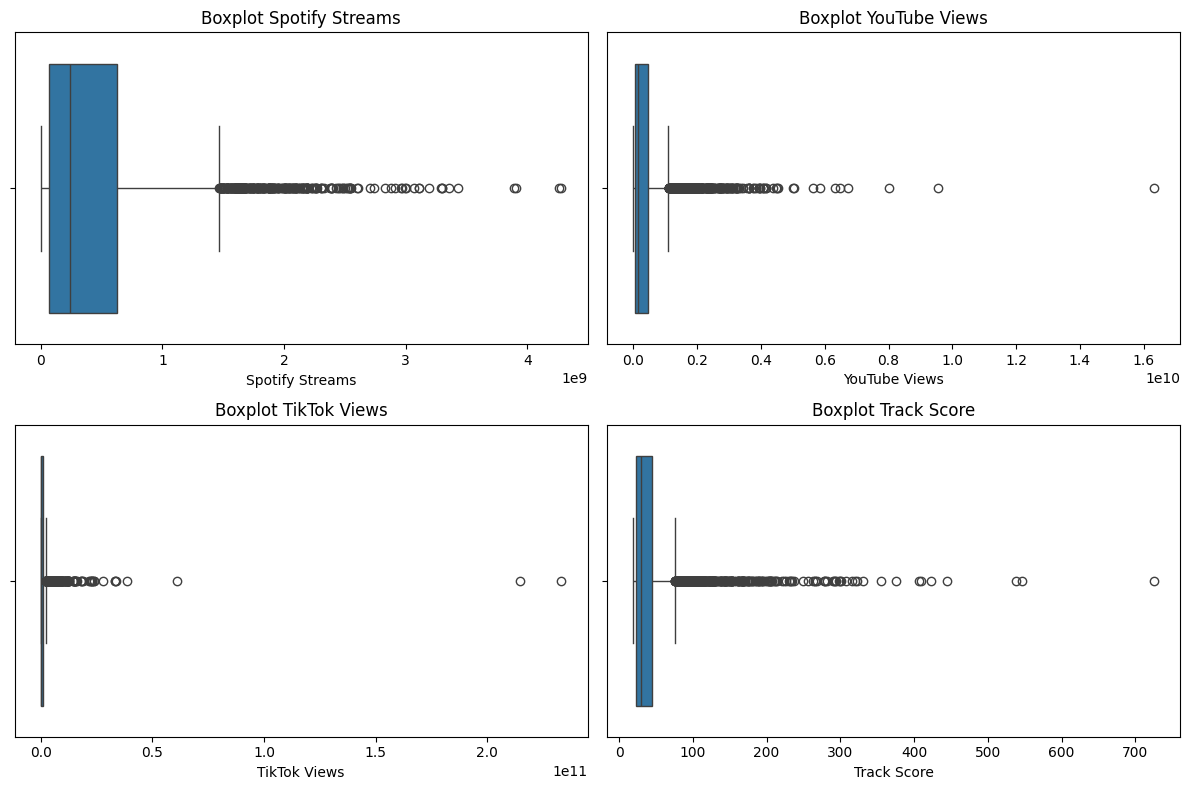

In [81]:
plt.figure(figsize=(12,8))

# Spotify Streams
plt.subplot(2,2,1)
sns.boxplot(x=df_musicas['Spotify Streams'])
plt.title('Boxplot Spotify Streams')

# YouTube Views
plt.subplot(2,2,2)
sns.boxplot(x=df_musicas['YouTube Views'])
plt.title('Boxplot YouTube Views')

# TikTok Views
plt.subplot(2,2,3)
sns.boxplot(x=df_musicas['TikTok Views'])
plt.title('Boxplot TikTok Views')

# Track Score
plt.subplot(2,2,4)
sns.boxplot(x=df_musicas['Track Score'])
plt.title('Boxplot Track Score')

plt.tight_layout()
plt.show()

## Histogramas

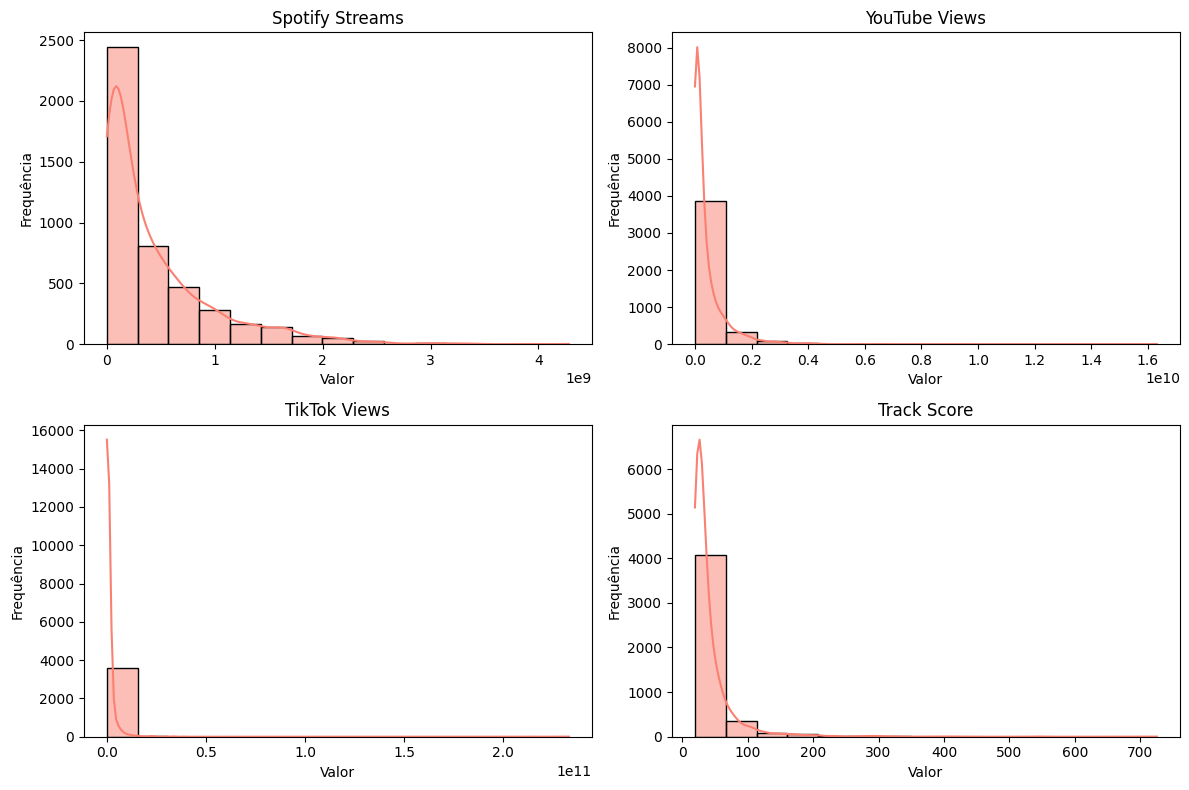

In [82]:
plt.figure(figsize=(12,8))

# Spotify Streams
plt.subplot(2,2,1)
sns.histplot(
    data=df_musicas,
    x='Spotify Streams',
    bins=15,
    kde=True,
    color='salmon'
)
plt.title('Spotify Streams')
plt.xlabel('Valor')
plt.ylabel('Frequência')


# YouTube Views
plt.subplot(2,2,2)
sns.histplot(
    data=df_musicas,
    x='YouTube Views',
    bins=15,
    kde=True,
    color='salmon'
)
plt.title('YouTube Views')
plt.xlabel('Valor')
plt.ylabel('Frequência')


# TikTok Views
plt.subplot(2,2,3)
sns.histplot(
    data=df_musicas,
    x='TikTok Views',
    bins=15,
    kde=True,
    color='salmon'
)
plt.title('TikTok Views')
plt.xlabel('Valor')
plt.ylabel('Frequência')


# Track Score
plt.subplot(2,2,4)
sns.histplot(
    data=df_musicas,
    x='Track Score',
    bins=15,
    kde=True,
    color='salmon'
)
plt.title('Track Score')
plt.xlabel('Valor')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()